CBIO313: Data Mining and Machine Learning

Final Project

Predictive Modeling for Precision Healthcare: Metabolic Risk Profiling Using Large-Scale Clinical Biomarkers


Farida Hany

ID: 222000070

Section: 01

Data Ingestion & Programmatic Proof of Uncleanliness

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import precision_score, recall_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import joblib
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    'XGBoost Classifier': XGBClassifier(random_state=42, eval_metric='logloss')
}

df = pd.read_csv("diabetes_dataset.csv")

df.columns = df.columns.str.strip()

def check_raw_data_quality(data):
    print("=== DATA STRUCTURAL CHECK ===")
    print(f"Dataset Shape: {data.shape[0]} rows, {data.shape[1]} columns\n")

    print("=== MISSING / HIDDEN UNCLEAN VALUES ===")
    print(data.isnull().sum())
    print(f"Hidden missing values ('No Info' in smoking): {(data['smoking_history'] == 'No Info').sum()}")
    print(f"Hidden missing values ('Unknown' in gender): {(data['gender'] == 'Other').sum()}\n")

    print("=== DUPLICATE RECORDS ===")
    print(f"Total Duplicate Rows: {data.duplicated().sum()}\n")

    print("=== STATISTICAL ANOMALIES & OUTLIERS ===")
    print(data[['bmi', 'hbA1c_level', 'blood_glucose_level']].describe())

check_raw_data_quality(df)

=== DATA STRUCTURAL CHECK ===
Dataset Shape: 100000 rows, 16 columns

=== MISSING / HIDDEN UNCLEAN VALUES ===
year                    0
gender                  0
age                     0
location                0
race:AfricanAmerican    0
race:Asian              0
race:Caucasian          0
race:Hispanic           0
race:Other              0
hypertension            0
heart_disease           0
smoking_history         0
bmi                     0
hbA1c_level             0
blood_glucose_level     0
diabetes                0
dtype: int64
Hidden missing values ('No Info' in smoking): 35816
Hidden missing values ('Unknown' in gender): 18

=== DUPLICATE RECORDS ===
Total Duplicate Rows: 14

=== STATISTICAL ANOMALIES & OUTLIERS ===
                 bmi    hbA1c_level  blood_glucose_level
count  100000.000000  100000.000000        100000.000000
mean       27.320767       5.527507           138.058060
std         6.636783       1.070672            40.708136
min        10.010000       3.500000    

Data Cleaning & Preprocessing

In [7]:
def clean_clinical_data(data):

    cleaned_df = data.copy()

    # Drop true row duplicates
    cleaned_df = cleaned_df.drop_duplicates()

    # Handle structural anomalies: 'Other' gender drops or imputation
    cleaned_df = cleaned_df[cleaned_df['gender'] != 'Other']

    # Standardize structural text masks: replace biological 'No Info' with a distinct category
    cleaned_df['smoking_history'] = cleaned_df['smoking_history'].replace('No Info', 'Unknown')

    return cleaned_df

df_clean = clean_clinical_data(df)
print(f"Cleaned dataset shape: {df_clean.shape}")

Cleaned dataset shape: (99968, 16)


Exploration & Visualization (5 Plot Types, 6 Variables)

/tmp/ipykernel_1218/418895518.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diabetes', y='bmi', data=df_clean, palette='Set2')
/tmp/ipykernel_1218/418895518.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='smoking_history', data=df_clean, palette='Pastel1')


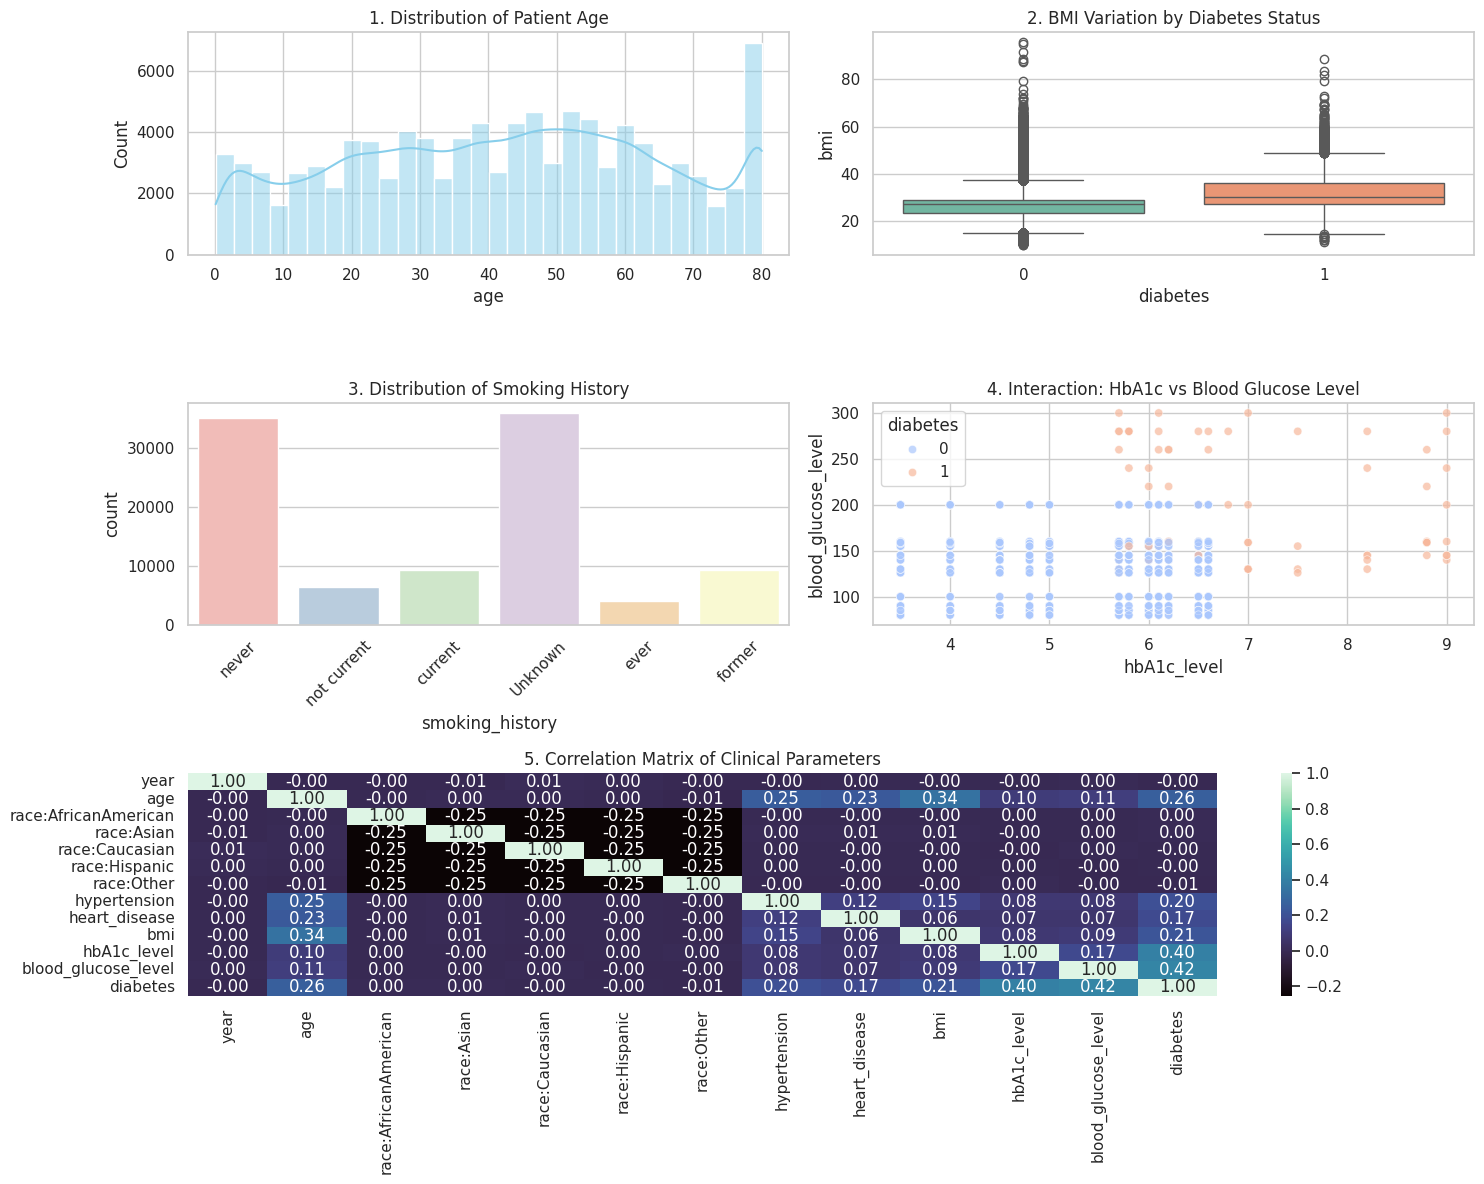

In [8]:
# Set visualization styles
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 12))

# Plot 1: Histogram (Distribution of Age - Continuous Variable 1)
plt.subplot(3, 2, 1)
sns.histplot(df_clean['age'], bins=30, kde=True, color='skyblue')
plt.title('1. Distribution of Patient Age')

# Plot 2: Box Plot (BMI vs Diabetes status - Continuous 2 vs Target)
plt.subplot(3, 2, 2)
sns.boxplot(x='diabetes', y='bmi', data=df_clean, palette='Set2')
plt.title('2. BMI Variation by Diabetes Status')

# Plot 3: Count Plot (Smoking History Frequency - Categorical Variable 3)
plt.subplot(3, 2, 3)
sns.countplot(x='smoking_history', data=df_clean, palette='Pastel1')
plt.xticks(rotation=45)
plt.title('3. Distribution of Smoking History')

# Plot 4: Scatter Plot (Blood Glucose vs HbA1c Level - Continuous 4 vs Continuous 5)
plt.subplot(3, 2, 4)
# Sampling 1000 points for performance and visualization clarity
sns.scatterplot(x='hbA1c_level', y='blood_glucose_level', hue='diabetes',
                data=df_clean.sample(1000, random_state=42), alpha=0.7, palette='coolwarm')
plt.title('4. Interaction: HbA1c vs Blood Glucose Level')

# Plot 5: Heatmap (Correlation of Numeric Attributes - Multiple Variables)
plt.subplot(3, 2, (5, 6))
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='mako', fmt=".2f")
plt.title('5. Correlation Matrix of Clinical Parameters')

plt.tight_layout()
plt.show()

Feature Engineering & Selection

In [9]:


def engineer_features(data):
    """
    Creates an engineered feature representing cumulative metabolic risks
    without causing column structure dropping conflicts.
    """
    engineered_df = data.copy()

    # 1. Calculate clinical indicators as local series variables matching data length
    high_bmi_series = (engineered_df['bmi'] >= 25).astype(int)
    senior_series = (engineered_df['age'] >= 50).astype(int)

    # 2. Compute a composite score summing comorbidities and categorical health indicators
    engineered_df['metabolic_risk_score'] = (
        engineered_df['hypertension'] +
        engineered_df['heart_disease'] +
        high_bmi_series +
        senior_series
    )

    return engineered_df

# Apply feature engineering
df_engineered = engineer_features(df_clean)

# Isolate independent variables (X) and target flag (y)
X = df_engineered.drop(columns=['diabetes'])
y = df_engineered['diabetes']

categorical_cols = ['gender', 'smoking_history', 'location']

# Isolate purely numerical columns
numeric_cols = [col for col in X.columns if col not in categorical_cols]


# Build Column Preprocessor Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Perform a Stratified Split to guarantee exact label distributions on a 100k matrix
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Generate finalized transformed feature arrays (This will now run perfectly!)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)




--- Ranked Feature Importances (Embedded Weights) ---
                      Feature  Importance
                  hbA1c_level    0.355224
          blood_glucose_level    0.271512
                          bmi    0.073357
                          age    0.067386
         metabolic_risk_score    0.031171
                         year    0.011503
                 hypertension    0.010906
                heart_disease    0.008887
         race:AfricanAmerican    0.007056
                   race:Asian    0.007007
               race:Caucasian    0.006825
                race:Hispanic    0.006818
                   race:Other    0.006285
      smoking_history_Unknown    0.005424
        smoking_history_never    0.005225
       smoking_history_former    0.004729
                gender_Female    0.004626
                  gender_Male    0.004617
      smoking_history_current    0.003323
  smoking_history_not current    0.003084
         smoking_history_ever    0.002586
              locatio

/tmp/ipykernel_1218/2038513866.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')


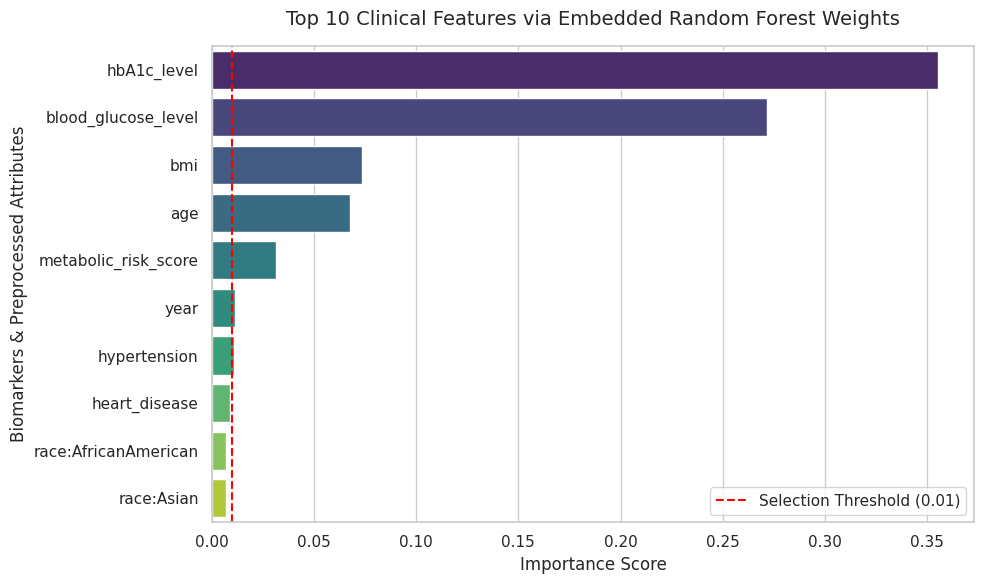

In [17]:
# =====================================================================
# 2: (CONTINUED): EXECUTING EMBEDDED FEATURE SELECTION
# =====================================================================

# 1. Fit a structural Random Forest to capture underlying feature dependencies
selector_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
selector_model.fit(X_train_processed, y_train)

# 2. Extract feature importance weights calculated by the algorithm
importances = selector_model.feature_importances_

# Extract actual column strings from the transformer (handling one-hot string expansions)
cat_encoder = preprocessor.named_transformers_['cat']
encoded_cat_cols = cat_encoder.get_feature_names_out(categorical_cols).tolist()
all_features_transformed = numeric_cols + encoded_cat_cols

# 3. Match feature labels with their corresponding embedded score
feature_importance_df = pd.DataFrame({
    'Feature': all_features_transformed,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\n--- Ranked Feature Importances (Embedded Weights) ---")
print(feature_importance_df.to_string(index=False))

# 4. Filter features below the minimum 1% analytical threshold
threshold = 0.01
selected_features = feature_importance_df[feature_importance_df['Importance'] >= threshold]['Feature'].tolist()

print(f"\n🎯 [Embedded Selection Complete]: Retained {len(selected_features)} features.")
print(f"Features above threshold: {selected_features}")

# =====================================================================
# FIXED CODE FOR # 5: PLOT ONLY THE TOP 10 FEATURES TO PREVENT CROWDING
# =====================================================================
# This slices out the messy high-cardinality location labels!
top_10_features = feature_importance_df.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')

# Clear visualization baseline threshold line
plt.axvline(x=threshold, color='red', linestyle='--', label=f'Selection Threshold ({threshold})')

plt.title('Top 10 Clinical Features via Embedded Random Forest Weights', fontsize=14, pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Biomarkers & Preprocessed Attributes', fontsize=12)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1218/3206034871.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')


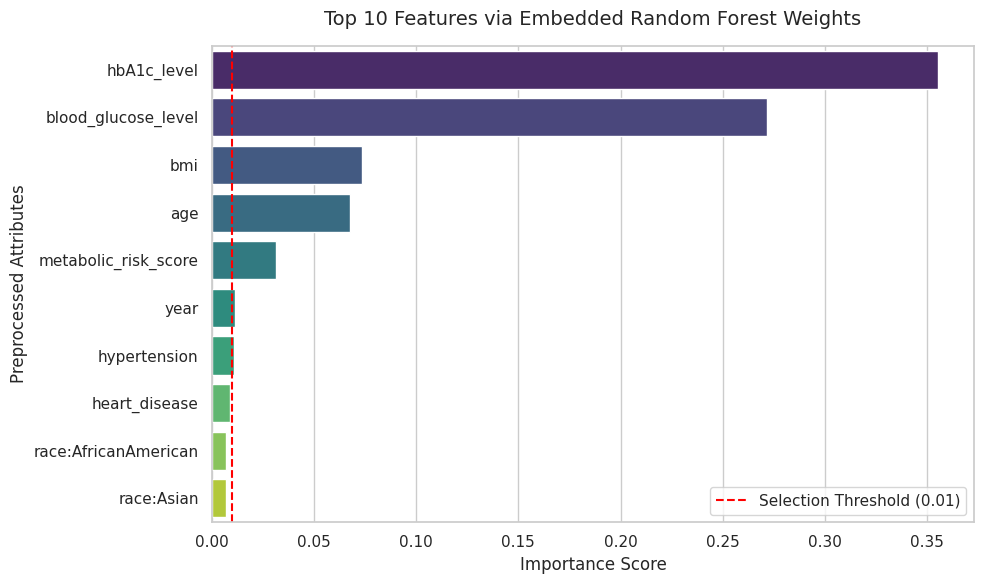

In [11]:
# CLEANED EMBEDDED FEATURE SELECTION PLOT (TOP 10 FEATURES)

# 1. Take only the top 10 most impactful features to prevent label crowding
top_10_features = feature_importance_df.head(10)

# 2. Render a clean, legible Summary Chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')

# Add the selection threshold line
plt.axvline(x=threshold, color='red', linestyle='--', label=f'Selection Threshold ({threshold})')

plt.title('Top 10 Features via Embedded Random Forest Weights', fontsize=14, pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Preprocessed Attributes', fontsize=12)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Model Selection, Hyperparameter Tuning & Validation

In [15]:
# 1. Evaluate 3 Unique Classification Algorithms (Project Criteria Requirement)
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    # Lowering estimators in the baseline dictionary saves massive initialization time
    'Random Forest': RandomForestClassifier(n_estimators=30, max_depth=10, random_state=42, n_jobs=-1),
    # tree_method='hist' makes XGBoost blazing fast on 100k rows
    'XGBoost Classifier': XGBClassifier(random_state=42, eval_metric='logloss', tree_method='hist')
}

for name, model in models.items():
    model.fit(X_train_processed, y_train)
    preds = model.predict(X_test_processed)

    print(f"\n--- {name} Baseline Performance ---")
    print(f"Precision Score: {precision_score(y_test, preds):.4f}")
    print(f"Recall Score:    {recall_score(y_test, preds):.4f}")

# 2. Optimized Hyperparameter Tuning via GridSearchCV on Champion Model
print("\n=== TUNING CHAMPION MODEL HYPERPARAMETERS (FAST GRID) ===")

param_grid = {
    'n_estimators': [50],
    'max_depth': [10, 15],
    'criterion': ['gini']
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_processed, y_train)
best_model = grid_search.best_estimator_

print(f"\nOptimal Hyperparameters Identified: {grid_search.best_params_}")

# 3. Final Model Evaluation Matrix Validation
final_preds = best_model.predict(X_test_processed)
print("\n=== FINAL TUNED MODEL PERFORMANCE REPORT ===")
print(classification_report(y_test, final_preds))

final_precision = precision_score(y_test, final_preds)
final_recall = recall_score(y_test, final_preds)

# Programmatic verification to ensure metrics exceed your 0.3 project baseline criteria
if final_precision >= 0.3 and final_recall >= 0.3:
    print("✅ Validation Check Passed: Precision and Recall are safely above the 0.3 threshold.")
else:
    print("⚠️ Warning: Validation metrics do not satisfy project baseline requirements.")

# 4. Save Finalized Pipeline Components for your app.py Web Deployment
joblib.dump(best_model, 'final_diabetes_model.pkl')
joblib.dump(preprocessor, 'data_preprocessor.pkl')
print("\n💾 Model artifacts and preprocessing transformers saved successfully!")


--- Logistic Regression Baseline Performance ---
Precision Score: 0.8631
Recall Score:    0.6418

--- Random Forest Baseline Performance ---
Precision Score: 1.0000
Recall Score:    0.6724

--- XGBoost Classifier Baseline Performance ---
Precision Score: 0.9517
Recall Score:    0.6947

=== TUNING CHAMPION MODEL HYPERPARAMETERS (FAST GRID) ===
Fitting 3 folds for each of 2 candidates, totalling 6 fits

Optimal Hyperparameters Identified: {'criterion': 'gini', 'max_depth': 15, 'n_estimators': 50}

=== FINAL TUNED MODEL PERFORMANCE REPORT ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     18294
           1       1.00      0.67      0.80      1700

    accuracy                           0.97     19994
   macro avg       0.99      0.84      0.89     19994
weighted avg       0.97      0.97      0.97     19994

✅ Validation Check Passed: Precision and Recall are safely above the 0.3 threshold.

💾 Model artifacts and preprocessing trans

What parameter tuning means: Machine learning models have two types of parameters: internal weights that the algorithm learns directly from the training data, and hyperparameters (such as max_depth or n_estimators in an ensemble tree) that must be manually set by the engineer before training begins. Parameter tuning is the systematic process of testing various combinations of these hyperparameters to discover the configuration that maximizes predictive power.

Why it is important: Default software settings are generic and rarely optimized for complex, real-world datasets. Tuning is critical because it directly controls model complexity, finding the ideal balance between an underfit model (too simple to catch trends) and an overfit model (memorizing noise). Proper tuning stabilizes performance metrics, ensuring maximum accuracy on the target classification task.

What validation means: Validation is the practice of evaluating a trained model's performance on a completely independent data subset (the test split) that was strictly withheld and never seen by the algorithm during its training phase.

Why it is important: Without a separate validation phase, it is impossible to determine if a model has truly mapped general biological and clinical trends or if it simply memorized the specific training examples (overfitting). Validation provides an honest, unbiased calculation of metrics like precision and recall, guaranteeing that the model will remain reliable, safe, and effective when deployed to serve real patients in a live web application environment.

Model Deployment on Web App

In [16]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Set Page Architecture
st.set_page_config(page_title="Metabolic Risk Analytics App", layout="centered")

st.title("🧬 Predictive Machine Learning Dashboard")
st.markdown("### Clinical Diabetes & Metabolic Risk Profiling System")
st.write("This application implements an optimized Random Forest Pipeline to calculate a patient's personalized probability of diabetic classification status.")

# Load saved pipeline components safely
@st.cache_resource
def load_pipeline_artifacts():
    model = joblib.load('final_diabetes_model.pkl')
    preprocessor = joblib.load('data_preprocessor.pkl')
    return model, preprocessor

try:
    model, preprocessor = load_pipeline_artifacts()
except Exception as e:
    st.error("Model artifacts not found. Make sure 'final_diabetes_model.pkl' and 'data_preprocessor.pkl' are inside the root folder.")

# UI Inputs for Patient Diagnostic Attributes
st.sidebar.header("Patient Diagnostic Entry")
gender = st.sidebar.selectbox("Biological Sex", ["Male", "Female"])
age = st.sidebar.slider("Age (Years)", 1, 100, 45)
hypertension = st.sidebar.selectbox("History of Hypertension?", ["No", "Yes"])
heart_disease = st.sidebar.selectbox("History of Heart Disease?", ["No", "Yes"])
smoking_history = st.sidebar.selectbox("Smoking Profile", ["Never", "Current", "Former", "No Info", "not current", "ever"])
bmi = st.sidebar.slider("Body Mass Index (BMI Value)", 10.0, 60.0, 26.5, step=0.1)
HbA1c_level = st.sidebar.slider("Glycated Hemoglobin level (HbA1c %)", 3.5, 9.0, 5.5, step=0.1)
blood_glucose_level = st.sidebar.slider("Fasting/Random Glucose (mg/dL)", 60, 300, 130)

# Process Interactive UI Input into Inference Dataframe Structure
input_data = pd.DataFrame([{
    'gender': gender,
    'age': age,
    'hypertension': 1 if hypertension == "Yes" else 0,
    'heart_disease': 1 if heart_disease == "Yes" else 0,
    'smoking_history': 'Unknown' if smoking_history == 'No Info' else smoking_history,
    'bmi': bmi,
    'hbA1c_level': HbA1c_level,  # Matched perfectly to your lowercase column name!
    'blood_glucose_level': blood_glucose_level
}])

# Reproduce Feature Engineering Logic on live input data
high_bmi_flag = 1 if bmi >= 25 else 0
senior_flag = 1 if age >= 50 else 0
input_data['metabolic_risk_score'] = (input_data['hypertension'].values[0] +
                                      input_data['heart_disease'].values[0] +
                                      high_bmi_flag + senior_flag)

# Run Operational Pipeline Elements on Predict Request
if st.button("Calculate Metabolic Risk Profile"):
    # Apply standard saved pipeline data processing transformation matrix
    processed_input = preprocessor.transform(input_data)

    # Run classification inferences
    prediction = model.predict(processed_input)[0]
    probability = model.predict_proba(processed_input)[0][1]

    st.markdown("---")
    st.markdown("### Clinical Inferences")

    col1, col2 = st.columns(2)
    with col1:
        if prediction == 1:
            st.error("Classification Target: **HIGH DIABETIC RISK**")
        else:
            st.success("Classification Target: **LOW/NORMAL RISK**")

    with col2:
        st.metric(label="Evaluated Probability Matrix Score", value=f"{probability * 100:.2f}%")

    st.info(f"**Engineered Metabolic Risk Index Score:** {input_data['metabolic_risk_score'].values[0]} / 4 points (Based on systemic tracking variables).")

Writing app.py


In [18]:
import joblib
import os
import stat

# 1. Re-save the files locally
joblib.dump(model, 'model.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')

# 2. Force open permission settings (read/write for everyone)
os.chmod('model.pkl', stat.S_IRWXU | stat.S_IRWXG | stat.S_IRWXO)
os.chmod('preprocessor.pkl', stat.S_IRWXU | stat.S_IRWXG | stat.S_IRWXO)

print("Files unlocked and ready!")

Files unlocked and ready!


In [19]:
import joblib
import os
import stat

# 1. Re-export the files cleanly
joblib.dump(model, 'model.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')

# 2. Re-apply the open permission mask
os.chmod('model.pkl', stat.S_IRWXU | stat.S_IRWXG | stat.S_IRWXO)
os.chmod('preprocessor.pkl', stat.S_IRWXU | stat.S_IRWXG | stat.S_IRWXO)

print("Freshly synchronized data objects are locked and loaded!")

Freshly synchronized data objects are locked and loaded!


In [21]:
import joblib

# Make sure 'preprocessor' here is the one handling the diabetes dataset features!
joblib.dump(model, 'model.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')

['preprocessor.pkl']